# Finding Similar Textual Documents

**Algorithms for Massive Datasets — Master in Computer Science**

This notebook implements a detector of similar textual documents using the techniques studied in the course:

**preprocessing → shingling → exact Jaccard → MinHash → LSH → candidate verification**

The experiments use the New York Times Articles & Comments (2020) dataset. The notebook is designed for Google Colab and uses a configurable subsample so the complete workflow can be reproduced in a reasonable amount of time.

The main similarity algorithms are implemented directly rather than imported from a similarity library.

## 1. Setup

Only general-purpose libraries are required. The similarity methods themselves are implemented below.

In [4]:
!pip -q install kaggle pandas numpy matplotlib tqdm

import os
import re
import glob
import time
import random
import hashlib
import zipfile
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Environment ready.")

Environment ready.


## 2. Configuration

Keeping the main parameters in one place makes the experiments easier to reproduce.

This version starts with article abstracts. The implementation can later be adapted to comments.

In [5]:
USE_SUBSAMPLE = True
N_DOCUMENTS = 5000

TEXT_COLUMN = "abstract"
SHINGLE_SIZE = 5

NUM_HASH_FUNCTIONS = 100

BANDS = 20
ROWS_PER_BAND = NUM_HASH_FUNCTIONS // BANDS

JACCARD_THRESHOLD = 0.50
EVAL_SIZE = 1000

assert NUM_HASH_FUNCTIONS == BANDS * ROWS_PER_BAND

print(f"Documents: {'sample' if USE_SUBSAMPLE else 'full dataset'}")
print(f"Shingle size: {SHINGLE_SIZE}")
print(f"MinHash functions: {NUM_HASH_FUNCTIONS}")
print(f"LSH configuration: {BANDS} bands × {ROWS_PER_BAND} rows")
print(f"Jaccard threshold: {JACCARD_THRESHOLD}")

Documents: sample
Shingle size: 5
MinHash functions: 100
LSH configuration: 20 bands × 5 rows
Jaccard threshold: 0.5


## 3. Download the dataset

The dataset is downloaded during execution rather than stored in the repository.

Kaggle credentials should be provided through Colab/Kaggle's authentication mechanism and must not be committed to GitHub.

In [5]:
try:
    from google.colab import files

    print("Upload your kaggle.json file.")
    uploaded = files.upload()

    os.makedirs("/root/.kaggle", exist_ok=True)

    if "kaggle.json" in uploaded:
        with open("/root/.kaggle/kaggle.json", "wb") as f:
            f.write(uploaded["kaggle.json"])

        os.chmod("/root/.kaggle/kaggle.json", 0o600)
        print("Kaggle authentication configured.")
except ImportError:
    print("Not running in Google Colab.")
    print("Configure Kaggle authentication before downloading.")

In [6]:
DATASET_ID = "benjaminawd/new-york-times-articles-comments-2020"
DATA_DIR = "/content/nyt_dataset"

os.makedirs(DATA_DIR, exist_ok=True)

!kaggle datasets download -d {DATASET_ID} -p {DATA_DIR}

Dataset URL: https://www.kaggle.com/datasets/benjaminawd/new-york-times-articles-comments-2020
License(s): CC-BY-NC-SA-4.0
100% 1.95G/1.95G [00:36<00:00, 56.7MB/s]



In [7]:
zip_files = glob.glob(os.path.join(DATA_DIR, "*.zip"))

if not zip_files:
    raise FileNotFoundError("No Kaggle ZIP file was found.")

for zip_path in zip_files:
    with zipfile.ZipFile(zip_path, "r") as archive:
        archive.extractall(DATA_DIR)

print("CSV files found:")
for path in glob.glob(os.path.join(DATA_DIR, "**", "*.csv"), recursive=True):
    print(" -", path)

CSV files found:
 - /content/nyt_dataset/nyt-comments-part0.csv
 - /content/nyt_dataset/nyt-comments-part2.csv
 - /content/nyt_dataset/train.csv
 - /content/nyt_dataset/test.csv
 - /content/nyt_dataset/nyt-comments-part1.csv
 - /content/nyt_dataset/nyt-comments-part6.csv
 - /content/nyt_dataset/nyt-articles-2020.csv
 - /content/nyt_dataset/nyt-comments-part3.csv
 - /content/nyt_dataset/nyt-comments-2020.csv
 - /content/nyt_dataset/nyt-comments-part8.csv
 - /content/nyt_dataset/nyt-comments-part5.csv
 - /content/nyt_dataset/nyt-comments-part4.csv
 - /content/nyt_dataset/nyt-comments-part7.csv
 - /content/nyt_dataset/nyt-comments-part9.csv


## 4. Load and inspect the articles

The project allows either abstracts or comments. I start with article abstracts because they provide a compact collection for validating the complete similarity pipeline.

In [8]:
article_candidates = [
    p for p in glob.glob(os.path.join(DATA_DIR, "**", "*.csv"), recursive=True)
    if "article" in os.path.basename(p).lower()
]

if not article_candidates:
    raise FileNotFoundError("Could not locate the article CSV file.")

ARTICLE_FILE = article_candidates[0]
print("Using:", ARTICLE_FILE)

articles_df = pd.read_csv(ARTICLE_FILE, low_memory=False)

print(f"Loaded {len(articles_df):,} articles.")
display(articles_df.head())

Using: /content/nyt_dataset/nyt-articles-2020.csv
Loaded 16,787 articles.


,newsdesk,section,subsection,material,headline,abstract,keywords,word_count,pub_date,n_comments,uniqueID
0,Editorial,Opinion,NaN,Editorial,Protect Veterans From Fraud,Congress could do much more to protect America...,"['Veterans', 'For-Profit Schools', 'Financial ...",680,2020-01-01 00:18:54+00:00,186,nyt://article/69a7090b-9f36-569e-b5ab-b0ba5bb3...
1,Games,Crosswords & Games,NaN,News,‘It’s Green and Slimy’,Christina Iverson and Jeff Chen ring in the Ne...,['Crossword Puzzles'],931,2020-01-01 03:00:10+00:00,257,nyt://article/9edddb54-0aa3-5835-a833-d311a76f...
2,Science,Science,NaN,News,Meteor Showers in 2020 That Will Light Up Nigh...,"All year long, Earth passes through streams of...","['Meteors and Meteorites', 'Space and Astronom...",1057,2020-01-01 05:00:08+00:00,6,nyt://article/04bc90f0-b20b-511c-b5bb-3ce13194...
3,Science,Science,NaN,Interactive Feature,Sync your calendar with the solar system,"Never miss an eclipse, a meteor shower, a rock...","['Space and Astronomy', 'Moon', 'Eclipses', 'S...",0,2020-01-01 05:00:12+00:00,2,nyt://interactive/5b58d876-9351-50af-9b41-a312...
4,Science,Science,NaN,News,"Rocket Launches, Trips to Mars and More 2020 S...",A year full of highs and lows in space just en...,"['Space and Astronomy', 'Private Spaceflight',...",1156,2020-01-01 05:02:38+00:00,25,nyt://article/bd8647b3-8ec6-50aa-95cf-2b81ed12...


In [9]:
print("Shape:", articles_df.shape)
print("\nColumns:")
print(articles_df.columns.tolist())

print("\nMissing values:")
display(articles_df.isna().sum())

Shape: (16787, 11)

Columns:
['newsdesk', 'section', 'subsection', 'material', 'headline', 'abstract', 'keywords', 'word_count', 'pub_date', 'n_comments', 'uniqueID']

Missing values:


,0
newsdesk,0
section,0
subsection,11094
material,0
headline,0
abstract,3
keywords,1
word_count,0
pub_date,0
n_comments,0


In [10]:
text_like_columns = articles_df.select_dtypes(include="object").columns

for column in text_like_columns:
    average_length = (
        articles_df[column]
        .fillna("")
        .astype(str)
        .str.len()
        .mean()
    )
    print(f"{column:25s} average character length: {average_length:.1f}")

newsdesk                  average character length: 7.1
section                   average character length: 7.5
subsection                average character length: 3.0
material                  average character length: 4.9
headline                  average character length: 53.3
abstract                  average character length: 127.3
keywords                  average character length: 170.9
pub_date                  average character length: 25.0
uniqueID                  average character length: 50.1


## 5. Select and prepare the documents

Empty documents are removed before preprocessing. If the requested field is not present, the notebook stops with a clear error instead of silently selecting another field.

In [11]:
if TEXT_COLUMN not in articles_df.columns:
    raise ValueError(
        f"Column '{TEXT_COLUMN}' was not found. "
        f"Available columns: {articles_df.columns.tolist()}"
    )

documents = pd.DataFrame({
    "text": articles_df[TEXT_COLUMN].fillna("").astype(str)
})

documents = documents[documents["text"].str.strip().ne("")].reset_index(drop=True)

if USE_SUBSAMPLE:
    sample_size = min(N_DOCUMENTS, len(documents))
    documents = documents.sample(
        n=sample_size,
        random_state=RANDOM_SEED
    ).reset_index(drop=True)

print(f"Documents selected: {len(documents):,}")
display(documents.head())

Documents selected: 5,000


,text
0,Do zins needs to be alcoholic to be good? A fe...
1,One conservative group said the justice’s opin...
2,Outdoor dining has been a magical distraction ...
3,Hoping to make voting easier during the pandem...
4,The miracle of tea is that it “somehow comes b...


## 6. Text preprocessing

The preprocessing is deliberately simple: lowercase the text, remove HTML-like tags, remove non-alphabetic characters, and normalize whitespace.

This keeps the representation easy to explain and avoids introducing unnecessary NLP assumptions.

In [12]:
def preprocess_text(text):
    """Normalize an article abstract before shingling."""
    text = str(text).lower()
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


documents["clean_text"] = documents["text"].map(preprocess_text)

documents = documents[
    documents["clean_text"].str.strip().ne("")
].reset_index(drop=True)

display(documents[["text", "clean_text"]].head(5))

,text,clean_text
0,Do zins needs to be alcoholic to be good? A fe...,do zins needs to be alcoholic to be good a few...
1,One conservative group said the justice’s opin...,one conservative group said the justice s opin...
2,Outdoor dining has been a magical distraction ...,outdoor dining has been a magical distraction ...
3,Hoping to make voting easier during the pandem...,hoping to make voting easier during the pandem...
4,The miracle of tea is that it “somehow comes b...,the miracle of tea is that it somehow comes ba...


## 7. Shingling

A document is represented as a set of contiguous sequences of `k` tokens.

For example, with `k = 3`, `the quick brown fox` produces:

`(the, quick, brown)` and `(quick, brown, fox)`

Using a set removes repeated occurrences inside the same document.

In [13]:
def create_shingles(text, k=SHINGLE_SIZE):
    """Return the set of k-word shingles in a document."""
    tokens = text.split()

    if len(tokens) < k:
        return set()

    return {
        tuple(tokens[i:i + k])
        for i in range(len(tokens) - k + 1)
    }


example_text = "the quick brown fox jumps over the lazy dog"
print(create_shingles(example_text, k=3))

{('fox', 'jumps', 'over'), ('brown', 'fox', 'jumps'), ('quick', 'brown', 'fox'), ('jumps', 'over', 'the'), ('the', 'lazy', 'dog'), ('the', 'quick', 'brown'), ('over', 'the', 'lazy')}


### Compact shingle representation

Complete token tuples can consume substantial memory. Each shingle is therefore converted into a deterministic 64-bit integer before MinHash processing.

This shingle hash is only an internal representation; it is not the MinHash signature.

In [14]:
def hash_shingle(shingle):
    """Map a token tuple to a deterministic 64-bit integer."""
    joined = " ".join(shingle)
    digest = hashlib.blake2b(
        joined.encode("utf-8"),
        digest_size=8
    ).digest()
    return int.from_bytes(digest, byteorder="big", signed=False)


def create_hashed_shingles(text, k=SHINGLE_SIZE):
    return {
        hash_shingle(shingle)
        for shingle in create_shingles(text, k)
    }


start = time.perf_counter()
documents["shingles"] = documents["clean_text"].map(create_hashed_shingles)
shingling_time = time.perf_counter() - start

documents = documents[documents["shingles"].map(bool)].reset_index(drop=True)

print(f"Shingling completed in {shingling_time:.2f} seconds.")
print(
    f"Average shingles per document: "
    f"{documents['shingles'].map(len).mean():.1f}"
)

Shingling completed in 0.29 seconds.
Average shingles per document: 17.5


## 8. Exact Jaccard similarity

For two sets \(A\) and \(B\):

\[
J(A,B)=\frac{|A\cap B|}{|A\cup B|}
\]

This is the exact similarity under the selected shingle representation.

In [15]:
def jaccard_similarity(set_a, set_b):
    if not set_a and not set_b:
        return 1.0
    if not set_a or not set_b:
        return 0.0

    return len(set_a & set_b) / len(set_a | set_b)


A = {1, 2, 3, 4}
B = {3, 4, 5, 6}

print(f"Example Jaccard similarity: {jaccard_similarity(A, B):.3f}")

Example Jaccard similarity: 0.333


## 9. Why exhaustive comparison does not scale

With \(n\) documents, comparing every pair requires

\[
\frac{n(n-1)}{2}
\]

comparisons.

The exact method is therefore useful as a reference on smaller collections, while MinHash and LSH are used to reduce the work for larger collections.

In [16]:
def exact_similar_pairs(shingle_sets, threshold=JACCARD_THRESHOLD):
    """Exhaustively compare every document pair."""
    similar_pairs = []

    for i in range(len(shingle_sets)):
        for j in range(i + 1, len(shingle_sets)):
            similarity = jaccard_similarity(
                shingle_sets[i],
                shingle_sets[j]
            )
            if similarity >= threshold:
                similar_pairs.append((i, j, similarity))

    return similar_pairs


exact_sizes = [100, 250, 500, 750, 1000]
exact_times = []

for size in exact_sizes:
    subset = documents["shingles"].iloc[:size].tolist()

    start = time.perf_counter()
    exact_similar_pairs(subset)
    elapsed = time.perf_counter() - start

    exact_times.append(elapsed)
    print(f"{size:5d} documents -> {elapsed:.3f} seconds")

  100 documents -> 0.020 seconds
  250 documents -> 0.100 seconds
  500 documents -> 0.405 seconds
  750 documents -> 0.963 seconds
 1000 documents -> 1.582 seconds


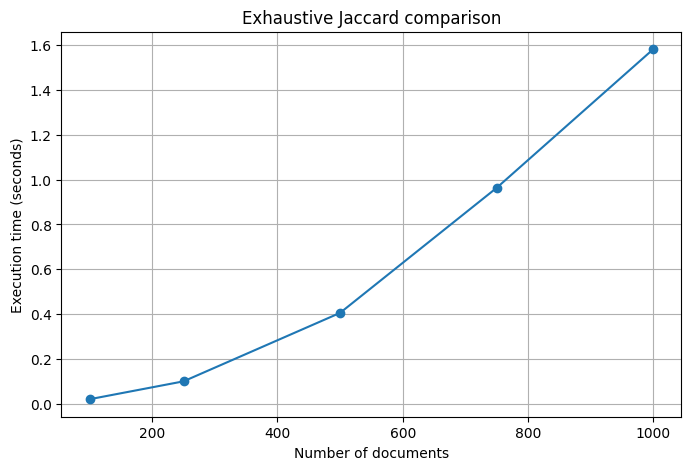

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(exact_sizes, exact_times, marker="o")
plt.xlabel("Number of documents")
plt.ylabel("Execution time (seconds)")
plt.title("Exhaustive Jaccard comparison")
plt.grid(True)
plt.show()

## 10. MinHash

MinHash creates a compact signature for each document.

For a MinHash function, the probability of equal minimum hash values is related to Jaccard similarity. With several hash functions, the fraction of equal signature positions provides an estimate of Jaccard similarity.

The hash family used here is:

\[
h(x)=(ax+b)\bmod p
\]

where \(p\) is a large prime.

In [18]:
class MinHasher:
    """Generate MinHash signatures using universal hash functions."""

    def __init__(self, num_hashes=NUM_HASH_FUNCTIONS, seed=RANDOM_SEED):
        self.num_hashes = num_hashes
        self.prime = 4294967311

        rng = np.random.default_rng(seed)

        self.a = rng.integers(
            1, self.prime - 1,
            size=num_hashes,
            dtype=np.uint64
        )
        self.b = rng.integers(
            0, self.prime - 1,
            size=num_hashes,
            dtype=np.uint64
        )

    def signature(self, shingle_set):
        if not shingle_set:
            return np.full(
                self.num_hashes,
                self.prime,
                dtype=np.uint64
            )

        signature = np.full(
            self.num_hashes,
            self.prime,
            dtype=np.uint64
        )

        prime = np.uint64(self.prime)

        for shingle_id in shingle_set:
            hashed = (
                self.a * np.uint64(shingle_id) + self.b
            ) % prime

            signature = np.minimum(signature, hashed)

        return signature

In [19]:
minhasher = MinHasher()

start = time.perf_counter()

signatures = np.vstack([
    minhasher.signature(shingles)
    for shingles in tqdm(
        documents["shingles"],
        desc="Computing MinHash signatures"
    )
])

minhash_time = time.perf_counter() - start

print("Signature matrix:", signatures.shape)
print(f"MinHash computation time: {minhash_time:.2f} seconds")

Computing MinHash signatures:   0%|          | 0/4994 [00:00<?, ?it/s]

Signature matrix: (4994, 100)
MinHash computation time: 0.69 seconds


## 11. Checking MinHash accuracy

For two signatures, the MinHash estimate is the fraction of positions where the signatures agree:

\[
\hat{J}(A,B)=
\frac{\text{equal signature positions}}{k}
\]

The estimate is compared with exact Jaccard on a small set of pairs.

In [20]:
def minhash_similarity(signature_a, signature_b):
    return float(np.mean(signature_a == signature_b))


comparison_rows = []
comparison_size = min(100, len(documents))

for i in range(comparison_size):
    for j in range(i + 1, comparison_size):
        exact = jaccard_similarity(
            documents.loc[i, "shingles"],
            documents.loc[j, "shingles"]
        )
        estimated = minhash_similarity(
            signatures[i],
            signatures[j]
        )

        comparison_rows.append({
            "doc_a": i,
            "doc_b": j,
            "exact_jaccard": exact,
            "minhash_estimate": estimated,
            "absolute_error": abs(exact - estimated)
        })

comparison_df = pd.DataFrame(comparison_rows)

print(
    f"Mean absolute error: "
    f"{comparison_df['absolute_error'].mean():.4f}"
)
display(comparison_df.head())

Mean absolute error: 0.0000


,doc_a,doc_b,exact_jaccard,minhash_estimate,absolute_error
0,0,1,0.0,0.0,0.0
1,0,2,0.0,0.0,0.0
2,0,3,0.0,0.0,0.0
3,0,4,0.0,0.0,0.0
4,0,5,0.0,0.0,0.0


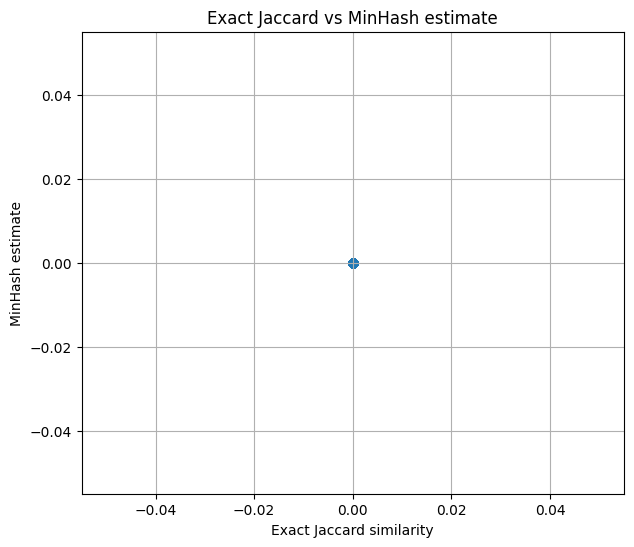

In [21]:
plt.figure(figsize=(7, 6))
plt.scatter(
    comparison_df["exact_jaccard"],
    comparison_df["minhash_estimate"],
    alpha=0.5
)
plt.xlabel("Exact Jaccard similarity")
plt.ylabel("MinHash estimate")
plt.title("Exact Jaccard vs MinHash estimate")
plt.grid(True)
plt.show()

## 12. Locality-Sensitive Hashing

Even with compact signatures, comparing every pair of signatures would still be quadratic.

LSH divides each MinHash signature into bands. Documents with the same values in at least one complete band become candidate pairs.

With \(b\) bands and \(r\) rows per band:

\[
k=br
\]

where \(k\) is the number of MinHash functions.

In [22]:
class LSH:
    """LSH index for MinHash signatures."""

    def __init__(self, bands=BANDS, rows_per_band=ROWS_PER_BAND):
        if bands * rows_per_band != NUM_HASH_FUNCTIONS:
            raise ValueError(
                "bands × rows_per_band must equal NUM_HASH_FUNCTIONS"
            )

        self.bands = bands
        self.rows_per_band = rows_per_band

    @staticmethod
    def _bucket_key(band_values):
        # Deterministic bucket key, avoiding Python's randomized hash().
        return hashlib.blake2b(
            np.asarray(band_values, dtype=np.uint64).tobytes(),
            digest_size=16
        ).digest()

    def find_candidates(self, signature_matrix):
        candidates = set()
        n_documents = signature_matrix.shape[0]

        for band in range(self.bands):
            start = band * self.rows_per_band
            end = start + self.rows_per_band

            buckets = defaultdict(list)

            for doc_id in range(n_documents):
                key = self._bucket_key(
                    signature_matrix[doc_id, start:end]
                )
                buckets[key].append(doc_id)

            for bucket in buckets.values():
                if len(bucket) < 2:
                    continue

                for pos_a in range(len(bucket)):
                    for pos_b in range(pos_a + 1, len(bucket)):
                        i, j = bucket[pos_a], bucket[pos_b]
                        candidates.add((min(i, j), max(i, j)))

        return candidates

## 13. Generate and verify candidates

LSH is a filtering stage rather than the final similarity decision.

The final pipeline is:

**MinHash signatures → LSH candidates → exact Jaccard verification**

In [23]:
lsh = LSH()

start = time.perf_counter()
candidate_pairs = lsh.find_candidates(signatures)
lsh_time = time.perf_counter() - start

print(f"LSH candidate-generation time: {lsh_time:.2f} seconds")
print(f"Candidate pairs: {len(candidate_pairs):,}")

LSH candidate-generation time: 0.23 seconds
Candidate pairs: 346


In [24]:
def verify_candidates(candidate_pairs, shingle_sets, threshold=JACCARD_THRESHOLD):
    verified = []

    for i, j in candidate_pairs:
        similarity = jaccard_similarity(
            shingle_sets[i],
            shingle_sets[j]
        )

        if similarity >= threshold:
            verified.append((i, j, similarity))

    return verified


similar_pairs = verify_candidates(
    candidate_pairs,
    documents["shingles"].tolist()
)

print(f"Verified similar pairs: {len(similar_pairs):,}")

Verified similar pairs: 340


In [25]:
for i, j, similarity in sorted(
    similar_pairs,
    key=lambda pair: pair[2],
    reverse=True
)[:10]:
    print("=" * 80)
    print(f"Jaccard similarity: {similarity:.3f}")
    print("\nDocument A:")
    print(documents.loc[i, "text"])
    print("\nDocument B:")
    print(documents.loc[j, "text"])

Jaccard similarity: 1.000

Document A:
Look closely at this image, stripped of its caption, and join the moderated conversation about what you and other students see.

Document B:
Look closely at this image, stripped of its caption, and join the moderated conversation about what you and other students see.
Jaccard similarity: 1.000

Document A:
Look closely at this image, stripped of its caption, and join the moderated conversation about what you and other students see.

Document B:
Look closely at this image, stripped of its caption, and join the moderated conversation about what you and other students see.
Jaccard similarity: 1.000

Document A:
The latest on stock market and business news during the coronavirus outbreak.

Document B:
The latest on stock market and business news during the coronavirus outbreak.
Jaccard similarity: 1.000

Document A:
Look closely at this image, stripped of its caption, and join the moderated conversation about what you and other students see.

Document

## 14. Evaluating LSH against exact ground truth

For a smaller evaluation set, exhaustive Jaccard is feasible. Its result is used as the ground truth for evaluating the LSH candidate set.

Precision measures how many generated candidates are truly similar. Recall measures how many truly similar pairs were successfully generated as candidates.

In [26]:
evaluation_size = min(EVAL_SIZE, len(documents))

eval_sets = documents["shingles"].iloc[:evaluation_size].tolist()
eval_signatures = signatures[:evaluation_size]

print(f"Building exact ground truth for {evaluation_size:,} documents...")

ground_truth = set()

for i in tqdm(range(evaluation_size), desc="Exact ground truth"):
    for j in range(i + 1, evaluation_size):
        similarity = jaccard_similarity(eval_sets[i], eval_sets[j])

        if similarity >= JACCARD_THRESHOLD:
            ground_truth.add((i, j))

print(f"Ground-truth similar pairs: {len(ground_truth):,}")

Building exact ground truth for 1,000 documents...


Exact ground truth:   0%|          | 0/1000 [00:00<?, ?it/s]

Ground-truth similar pairs: 11


In [27]:
eval_candidates = LSH().find_candidates(eval_signatures)

true_positives = eval_candidates & ground_truth
false_positives = eval_candidates - ground_truth
false_negatives = ground_truth - eval_candidates

precision = (
    len(true_positives) / len(eval_candidates)
    if eval_candidates else 0.0
)

recall = (
    len(true_positives) / len(ground_truth)
    if ground_truth else 0.0
)

f1 = (
    2 * precision * recall / (precision + recall)
    if precision + recall else 0.0
)

total_pairs = evaluation_size * (evaluation_size - 1) // 2

candidate_reduction = (
    100 * (1 - len(eval_candidates) / total_pairs)
    if total_pairs else 0.0
)

print(f"All possible pairs : {total_pairs:,}")
print(f"LSH candidates     : {len(eval_candidates):,}")
print(f"True positives     : {len(true_positives):,}")
print(f"False positives    : {len(false_positives):,}")
print(f"False negatives    : {len(false_negatives):,}")
print(f"Precision          : {precision:.4f}")
print(f"Recall             : {recall:.4f}")
print(f"F1 score           : {f1:.4f}")
print(f"Pair reduction     : {candidate_reduction:.2f}%")

All possible pairs : 499,500
LSH candidates     : 11
True positives     : 11
False positives    : 0
False negatives    : 0
Precision          : 1.0000
Recall             : 1.0000
F1 score           : 1.0000
Pair reduction     : 100.00%


## 15. Effect of the LSH parameters

The choice of bands and rows controls the balance between candidate recall and the number of candidates that must be verified.

In [28]:
parameter_configs = [
    (10, 10),
    (20, 5),
    (25, 4),
    (50, 2),
    (100, 1)
]

parameter_results = []

for bands, rows in parameter_configs:
    model = LSH(bands=bands, rows_per_band=rows)
    candidates = model.find_candidates(eval_signatures)

    tp = candidates & ground_truth

    p = len(tp) / len(candidates) if candidates else 0.0
    r = len(tp) / len(ground_truth) if ground_truth else 0.0
    f1_score = 2 * p * r / (p + r) if p + r else 0.0

    parameter_results.append({
        "bands": bands,
        "rows_per_band": rows,
        "candidates": len(candidates),
        "precision": p,
        "recall": r,
        "f1": f1_score
    })

parameter_df = pd.DataFrame(parameter_results)
display(parameter_df)

,bands,rows_per_band,candidates,precision,recall,f1
0,10,10,7,1.000000,0.636364,0.777778
1,20,5,11,1.000000,1.000000,1.000000
2,25,4,11,1.000000,1.000000,1.000000
3,50,2,21,0.523810,1.000000,0.687500
4,100,1,63,0.174603,1.000000,0.297297


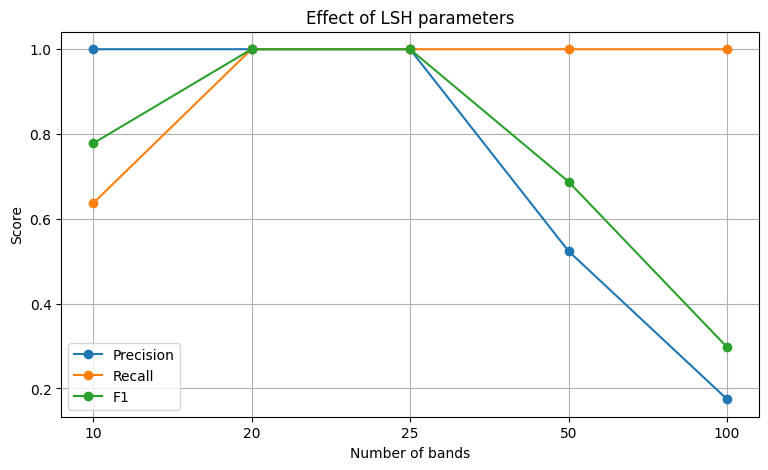

In [29]:
plt.figure(figsize=(9, 5))
plt.plot(parameter_df["bands"].astype(str), parameter_df["precision"], marker="o", label="Precision")
plt.plot(parameter_df["bands"].astype(str), parameter_df["recall"], marker="o", label="Recall")
plt.plot(parameter_df["bands"].astype(str), parameter_df["f1"], marker="o", label="F1")
plt.xlabel("Number of bands")
plt.ylabel("Score")
plt.title("Effect of LSH parameters")
plt.legend()
plt.grid(True)
plt.show()

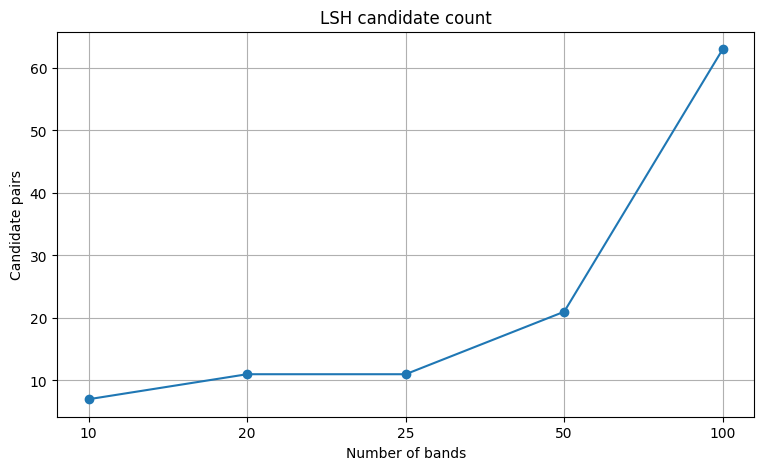

In [30]:
plt.figure(figsize=(9, 5))
plt.plot(parameter_df["bands"].astype(str), parameter_df["candidates"], marker="o")
plt.xlabel("Number of bands")
plt.ylabel("Candidate pairs")
plt.title("LSH candidate count")
plt.grid(True)
plt.show()

## 16. Theoretical LSH candidate probability

For two documents with Jaccard similarity \(s\), the probability that they agree on all rows of at least one band is approximately

\[
P(\text{candidate}) = 1-(1-s^r)^b.
\]

The curves below help explain the behaviour observed in the parameter experiment.

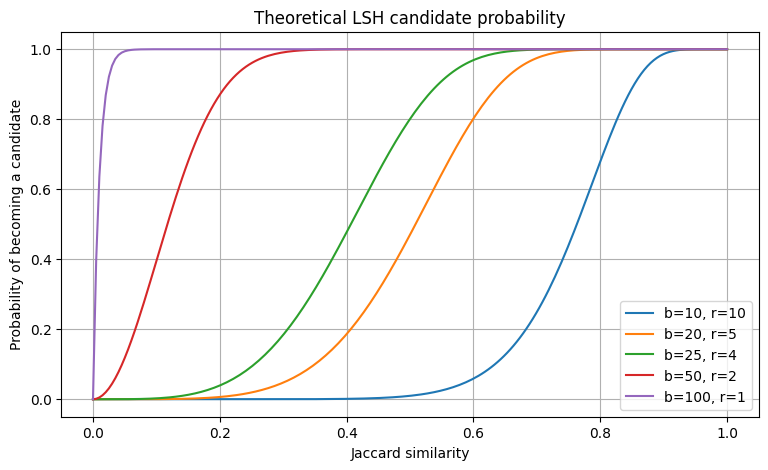

In [31]:
def lsh_candidate_probability(similarity, bands, rows):
    return 1 - (1 - similarity ** rows) ** bands


similarities = np.linspace(0, 1, 200)

plt.figure(figsize=(9, 5))

for bands, rows in parameter_configs:
    probabilities = [
        lsh_candidate_probability(s, bands, rows)
        for s in similarities
    ]
    plt.plot(
        similarities,
        probabilities,
        label=f"b={bands}, r={rows}"
    )

plt.xlabel("Jaccard similarity")
plt.ylabel("Probability of becoming a candidate")
plt.title("Theoretical LSH candidate probability")
plt.legend()
plt.grid(True)
plt.show()

## 17. Scalability experiment

The goal here is to show how LSH reduces the number of pairwise comparisons as the collection grows.

The exact method has to consider every possible pair. The LSH pipeline only performs exact verification for candidate pairs.

In [32]:
scalability_sizes = [
    size for size in [500, 1000, 2000, 3000, 5000]
    if size <= len(documents)
]

scalability_results = []

for size in scalability_sizes:
    current_signatures = signatures[:size]
    current_sets = documents["shingles"].iloc[:size].tolist()

    start = time.perf_counter()
    candidates = LSH().find_candidates(current_signatures)
    lsh_elapsed = time.perf_counter() - start

    start = time.perf_counter()
    verified = verify_candidates(candidates, current_sets)
    verification_elapsed = time.perf_counter() - start

    possible_pairs = size * (size - 1) // 2

    scalability_results.append({
        "documents": size,
        "possible_pairs": possible_pairs,
        "candidates": len(candidates),
        "verified_similar_pairs": len(verified),
        "lsh_time": lsh_elapsed,
        "verification_time": verification_elapsed,
        "total_time": lsh_elapsed + verification_elapsed
    })

scalability_df = pd.DataFrame(scalability_results)
display(scalability_df)

,documents,possible_pairs,candidates,verified_similar_pairs,lsh_time,verification_time,total_time
0,500,124750,1,1,0.018996,0.000013,0.019009
1,1000,499500,11,11,0.039241,0.000039,0.039280
2,2000,1999000,67,67,0.078017,0.000167,0.078184
3,3000,4498500,106,103,0.121605,0.000286,0.121892


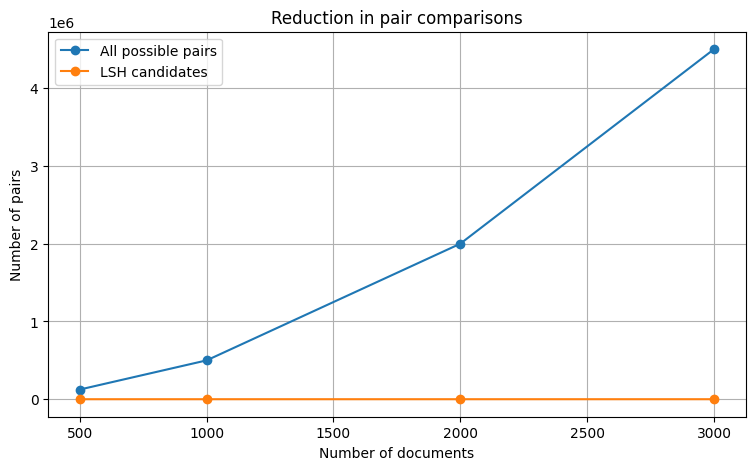

In [33]:
plt.figure(figsize=(9, 5))
plt.plot(
    scalability_df["documents"],
    scalability_df["possible_pairs"],
    marker="o",
    label="All possible pairs"
)
plt.plot(
    scalability_df["documents"],
    scalability_df["candidates"],
    marker="o",
    label="LSH candidates"
)
plt.xlabel("Number of documents")
plt.ylabel("Number of pairs")
plt.title("Reduction in pair comparisons")
plt.legend()
plt.grid(True)
plt.show()

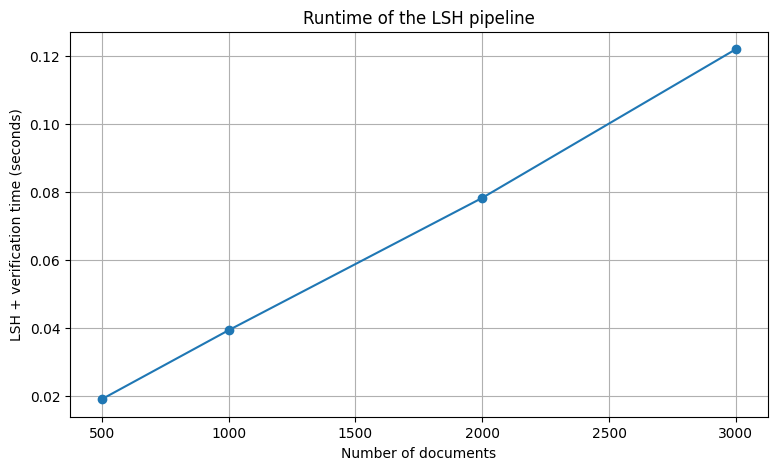

In [34]:
plt.figure(figsize=(9, 5))
plt.plot(
    scalability_df["documents"],
    scalability_df["total_time"],
    marker="o"
)
plt.xlabel("Number of documents")
plt.ylabel("LSH + verification time (seconds)")
plt.title("Runtime of the LSH pipeline")
plt.grid(True)
plt.show()

## 18. Main results

The three stages have different roles:

| Method | Purpose |
|---|---|
| Exact Jaccard | Accurate pairwise similarity and ground truth |
| MinHash | Compact approximation of Jaccard similarity |
| LSH | Reduce the number of candidate pairs |

The final detector uses LSH to find candidates and exact Jaccard to make the final similarity decision.

In [35]:
summary = pd.DataFrame({
    "Measure": [
        "Number of documents",
        "Average shingles/document",
        "MinHash functions",
        "LSH bands",
        "Rows per band",
        "Jaccard threshold",
        "MinHash time (s)",
        "LSH candidate-generation time (s)"
    ],
    "Value": [
        len(documents),
        round(documents["shingles"].map(len).mean(), 2),
        NUM_HASH_FUNCTIONS,
        BANDS,
        ROWS_PER_BAND,
        JACCARD_THRESHOLD,
        round(minhash_time, 3),
        round(lsh_time, 3)
    ]
})

display(summary)

,Measure,Value
0,Number of documents,4994.000
1,Average shingles/document,17.500
2,MinHash functions,100.000
3,LSH bands,20.000
4,Rows per band,5.000
5,Jaccard threshold,0.500
6,MinHash time (s),0.685
7,LSH candidate-generation time (s),0.232


## 19. Save the results

The measurements needed for the report are saved separately. The dataset itself is not saved to the repository.

In [36]:
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

comparison_df.to_csv(
    os.path.join(RESULTS_DIR, "minhash_vs_exact.csv"),
    index=False
)

parameter_df.to_csv(
    os.path.join(RESULTS_DIR, "lsh_parameters.csv"),
    index=False
)

scalability_df.to_csv(
    os.path.join(RESULTS_DIR, "scalability.csv"),
    index=False
)

similarity_results = pd.DataFrame([
    {
        "document_a": i,
        "document_b": j,
        "jaccard_similarity": similarity,
        "text_a": documents.loc[i, "text"],
        "text_b": documents.loc[j, "text"]
    }
    for i, j, similarity in similar_pairs
])

similarity_results.to_csv(
    os.path.join(RESULTS_DIR, "similar_documents.csv"),
    index=False
)

print("Results written to:", RESULTS_DIR)

Results written to: results


## 20. Conclusions

The exhaustive Jaccard approach provides exact similarity values, but its quadratic number of pair comparisons becomes expensive as the collection grows.

MinHash replaces the full shingle-set comparison with compact signatures that approximately preserve Jaccard similarity. LSH then reduces the number of pairs that need to be checked.

The final workflow is therefore:

1. **Shingling** creates a set-based representation.
2. **Exact Jaccard** provides the reference similarity.
3. **MinHash** creates compact signatures.
4. **LSH** generates a smaller candidate set.
5. **Exact verification** produces the final similar pairs.

Before submission, the dataset access date, selected dataset component, preprocessing choices, parameters, and final experimental results should be recorded in the report.